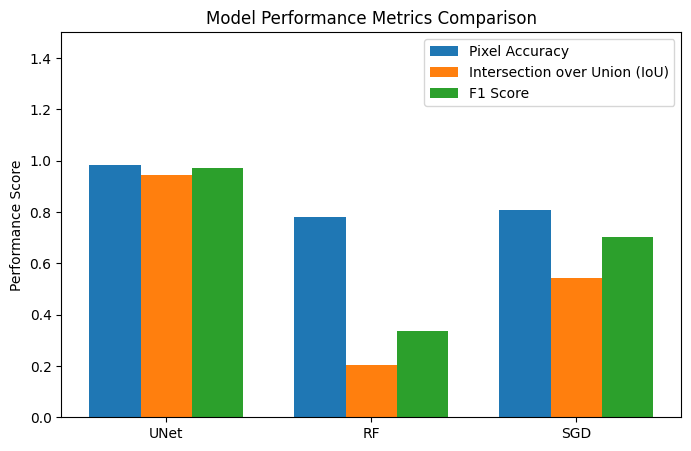

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

figuresDir = Path("..") / "reports" / "figures"
unet_metrics = np.load(figuresDir / "unet_metrics.npz")
rf_metrics = np.load(figuresDir / "rf_metrics.npz")
sgd_metrics = np.load(figuresDir / "sgd_metrics.npz")
trainLoss = np.load(figuresDir / "train_loss.npy")
valLoss = np.load(figuresDir / "val_loss.npy")


pixelAcc = [float(unet_metrics["pixel_acc"]), float(rf_metrics["pixel_acc"]), float(sgd_metrics["pixel_acc"])]
iou = [float(unet_metrics["iou"]), float(rf_metrics["iou"]), float(sgd_metrics["iou"])]
f1 = [float(unet_metrics["f1"]), float(rf_metrics["f1"]), float(sgd_metrics["f1"])]

labels = ["UNet", "RF", "SGD"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, pixelAcc, width, label = "Pixel Accuracy")
plt.bar(x, iou, width, label = "Intersection over Union (IoU)")
plt.bar(x + width, f1, width, label = "F1 Score")

plt.ylabel("Performance Score")
plt.title("Model Performance Metrics Comparison")
plt.xticks(x, labels)
plt.ylim(0, 1.5)
plt.legend()
plt.show()




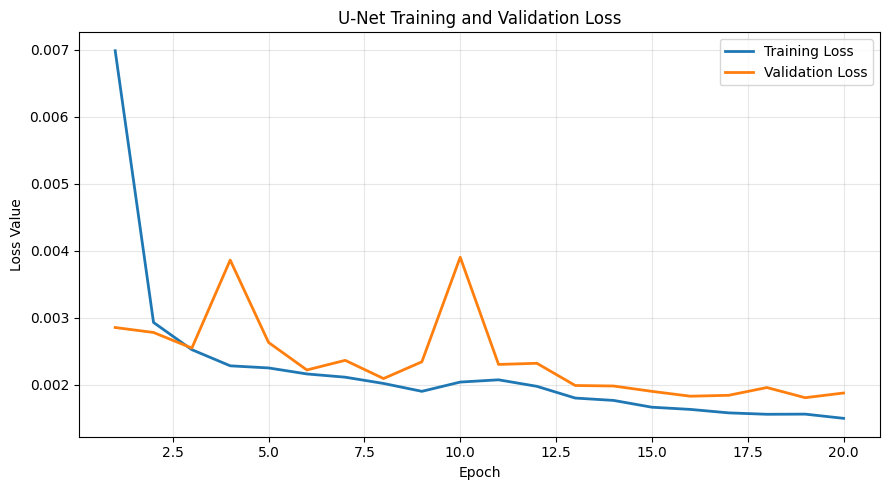

In [ ]:
epochsTrain = np.arange(1, len(trainLoss) + 1)
epochsVal = np.arange(1, len(valLoss) + 1)


plt.figure(figsize=(9, 5))
plt.plot(epochsTrain, trainLoss, label = "Training Loss", linewidth = 2)
plt.plot(epochsVal, valLoss, label = "Validation Loss", linewidth = 2)
plt.xlabel("Epoch")
plt.ylabel("Loss Function Value")
plt.title("U-Net Training and Validation Loss")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

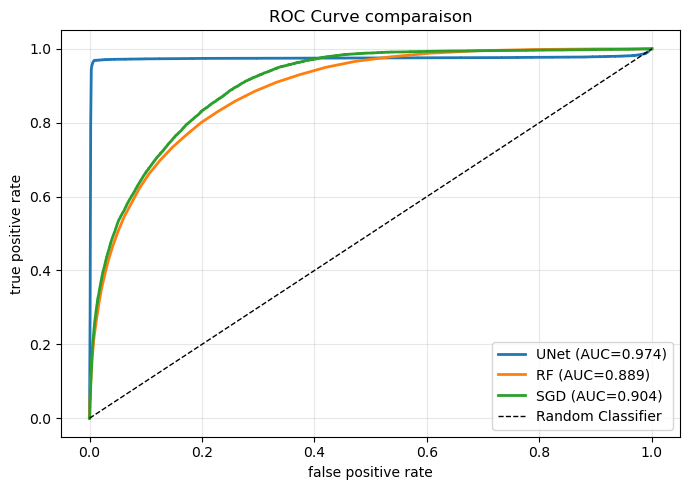

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(unet_metrics['fpr'], unet_metrics['tpr'], label=f"UNet (AUC={unet_metrics['roc_auc']:.3f})", linewidth=2)
plt.plot(rf_metrics['fpr'], rf_metrics['tpr'], label=f"RF (AUC={rf_metrics['roc_auc']:.3f})", linewidth=2)
plt.plot(sgd_metrics['fpr'], sgd_metrics['tpr'], label=f"SGD (AUC={sgd_metrics['roc_auc']:.3f})", linewidth=2)
plt.plot([0,1], [0,1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()
